# Distributions of Radiological Background

## Units

cm, GeV/c, ns

for both the ROOT and HEPEVT files

## LAr Geometry

X is the drift direction, vertical \
Xmin = -425.0cm \
Xmax = 425.08cm \
Cathode = -325cm \
CRP = 325cm \
Ymin = -753.8024cm \
Ymax = 753.8024cm \
Zmin = -107.0cm \
Zmax = 2198.88cm

In [1]:
import ROOT
import numpy as np
import pandas
import matplotlib.pyplot as plt

In [2]:
InputFilePath = "/Users/yuntse/data/lartpc_rd/gampix/gen/dune/fullgeoanatruth-vd1x8x14-1000_code.root"
InputTreeName = "FullGeoAnaTruth"

In [3]:
%%time
rootdf = ROOT.RDataFrame(InputTreeName, InputFilePath)
rootdf.Describe()

CPU times: user 190 ms, sys: 25.7 ms, total: 216 ms
Wall time: 267 ms


Dataframe from TChain FullGeoAnaTruth in file /Users/yuntse/data/lartpc_rd/gampix/gen/dune/fullgeoanatruth-vd1x8x14-1000_code.root

Property                Value
--------                -----
Columns in total           15
Columns from defines        0
Event loops run             0
Processing slots            1

Column          Type            Origin
------          ----            ------
Ekin            Double_t        Dataset
Etot            Double_t        Dataset
event           Int_t           Dataset
labelcode       UInt_t          Dataset
mass            Double_t        Dataset
pdg_code        Int_t           Dataset
px              Double_t        Dataset
py              Double_t        Dataset
pz              Double_t        Dataset
run             Int_t           Dataset
subrun          Int_t           Dataset
t               Double_t        Dataset
x               Double_t        Dataset
y               Double_t        Dataset
z               Double_t        Dataset

In [4]:
%%time
df = pandas.DataFrame(rootdf.AsNumpy())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132301297 entries, 0 to 132301296
Data columns (total 15 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Ekin       float64
 1   Etot       float64
 2   event      int32  
 3   labelcode  uint32 
 4   mass       float64
 5   pdg_code   int32  
 6   px         float64
 7   py         float64
 8   pz         float64
 9   run        int32  
 10  subrun     int32  
 11  t          float64
 12  x          float64
 13  y          float64
 14  z          float64
dtypes: float64(10), int32(4), uint32(1)
memory usage: 12.3 GB
CPU times: user 1min 5s, sys: 15.7 s, total: 1min 21s
Wall time: 2min 56s


In [5]:
try:
    LabelTreeName = InputTreeName + "_LabelMap"
    FInput = ROOT.TFile(InputFilePath, "READ")
    LabelTree = FInput.Get(InputTreeName + "_LabelMap")
    if not LabelTree: raise RuntimeError(f"Can't read tree '{LabelTreeName}' in '{InputFilePath}.")
except:
    try: FInput.Close()
    except AttributeError: pass
    raise
labelToCode = {}
codeToLabel = {}
for row in LabelTree:
    label = str(row.label)
    code = row.labelCode
    labelToCode[label] = code
    codeToLabel[code] = label
# for
labelDF = pandas.DataFrame(dict(labelCode=codeToLabel.keys(), label=codeToLabel.values()))
labelDF

,labelCode,label
0,3397053793,CryostatNGammasAtLAr
1,3364292438,CavernNGammasAtLAr
2,544797560,CavernwallNeutronsAtLAr
3,655153075,Rn222ChainGenInPDS
4,3304492435,foamGammasAtLAr
5,3641398812,CavernwallGammasAtLAr
6,871716743,Th232ChainGenInAnode
7,597414879,U238ChainGenInAnode
8,722243711,K40GenInAnode
9,3162635185,Rn222ChainFromBi210GenInUpperMesh


In [6]:
# example palette (30 colors)
palette = np.vstack([
    plt.get_cmap("tab20").colors,
    plt.get_cmap("tab20b").colors,
    plt.get_cmap("tab20c").colors,
])[:30]

# build mapping using labelDF order
code_to_color = dict(zip(labelDF["labelCode"], palette))

# add to labelDF
labelDF["color"] = labelDF["labelCode"].map(code_to_color)
labelDF

,labelCode,label,color
0,3397053793,CryostatNGammasAtLAr,"[0.12156862745098039, 0.4666666666666667, 0.70..."
1,3364292438,CavernNGammasAtLAr,"[0.6823529411764706, 0.7803921568627451, 0.909..."
2,544797560,CavernwallNeutronsAtLAr,"[1.0, 0.4980392156862745, 0.054901960784313725]"
3,655153075,Rn222ChainGenInPDS,"[1.0, 0.7333333333333333, 0.47058823529411764]"
4,3304492435,foamGammasAtLAr,"[0.17254901960784313, 0.6274509803921569, 0.17..."
5,3641398812,CavernwallGammasAtLAr,"[0.596078431372549, 0.8745098039215686, 0.5411..."
6,871716743,Th232ChainGenInAnode,"[0.8392156862745098, 0.15294117647058825, 0.15..."
7,597414879,U238ChainGenInAnode,"[1.0, 0.596078431372549, 0.5882352941176471]"
8,722243711,K40GenInAnode,"[0.5803921568627451, 0.403921568627451, 0.7411..."
9,3162635185,Rn222ChainFromBi210GenInUpperMesh,"[0.7725490196078432, 0.6901960784313725, 0.835..."


In [7]:
df.Ekin.max(), df.Ekin.min(), df.Etot.max(), df.Etot.min()

(0.009300796198411879, 0.0, 3.7362019999999996, 0.0)

In [8]:
labelDF.loc[1]['labelCode']

np.int64(3364292438)

In [9]:
Ebins = np.linspace(0, 10., 101)

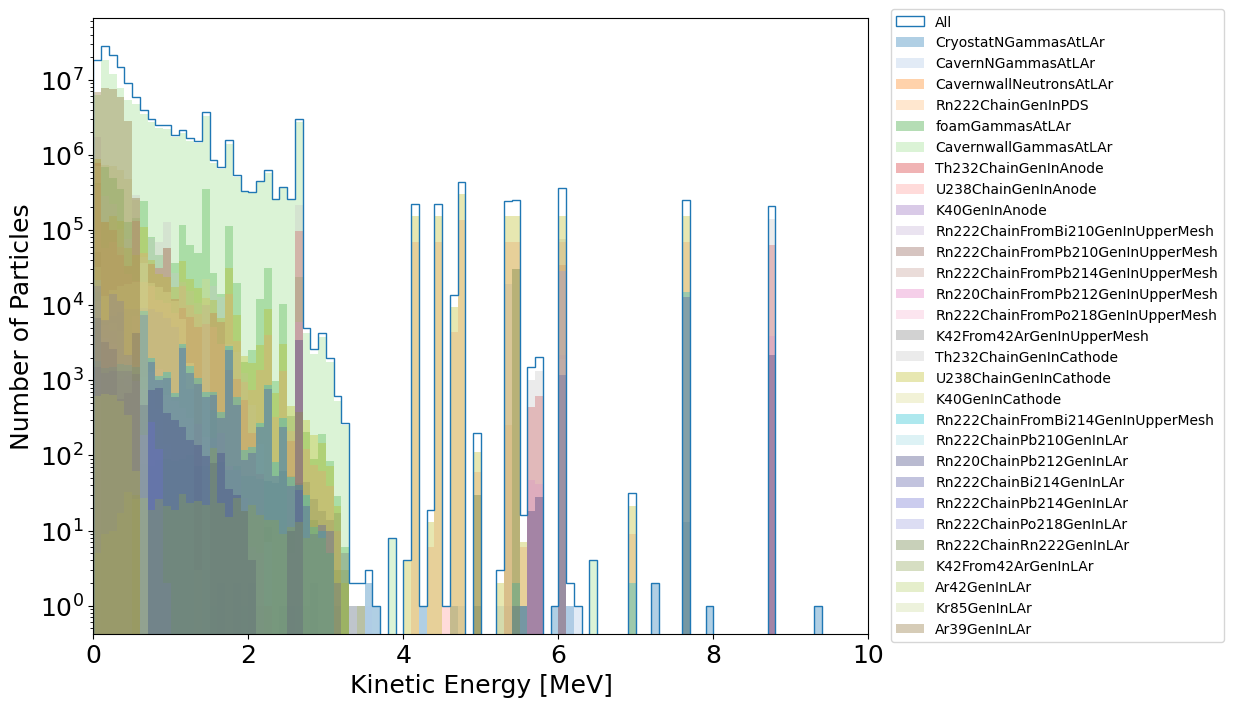

In [18]:
fig, ax = plt.subplots(figsize = (10, 8))

fontS = 18

ax.hist(df.Ekin*1000, bins = Ebins, histtype = 'step', label = 'All')
for radMap in labelDF.itertuples(index = False):
    ax.hist(df.loc[df['labelcode'].eq(radMap.labelCode), 'Ekin']*1000, bins = Ebins, histtype = 'stepfilled', alpha = 0.35,
            label = radMap.label, color = radMap.color)

ax.set_xlabel('Kinetic Energy [MeV]', fontsize = fontS)
ax.set_ylabel('Number of Particles', fontsize = fontS)
ax.tick_params(axis = "both", labelsize = fontS)
ax.set_xlim([0, 10])
ax.set_yscale('log')
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5))

In [11]:
df.Ekin

0            0.000144
1            0.000342
2            0.000412
3            0.000357
4            0.000326
               ...   
132301292    0.000170
132301293    0.001214
132301294    0.000304
132301295    0.000262
132301296    0.001740
Name: Ekin, Length: 132301297, dtype: float64

In [12]:
top5 = ( df["labelcode"].value_counts().head(5).rename_axis('labelCode').reset_index(name = 'count') )
# top5_codes = top5_codes.rename(columns = {"index": "labelCode"})
top5

top5_with_names = top5.merge(labelDF[["labelCode", "label", "color"]], on = "labelCode", how = "left")
top5_with_names

,labelCode,count,label,color
0,3641398812,83739545,CavernwallGammasAtLAr,"[0.596078431372549, 0.8745098039215686, 0.5411..."
1,1418910898,31122409,Ar39GenInLAr,"[0.5490196078431373, 0.42745098039215684, 0.19..."
2,3444384594,3604739,Th232ChainGenInCathode,"[0.7803921568627451, 0.7803921568627451, 0.780..."
3,3150018087,3546825,Kr85GenInLAr,"[0.807843137254902, 0.8588235294117647, 0.6117..."
4,3304492435,3512293,foamGammasAtLAr,"[0.17254901960784313, 0.6274509803921569, 0.17..."


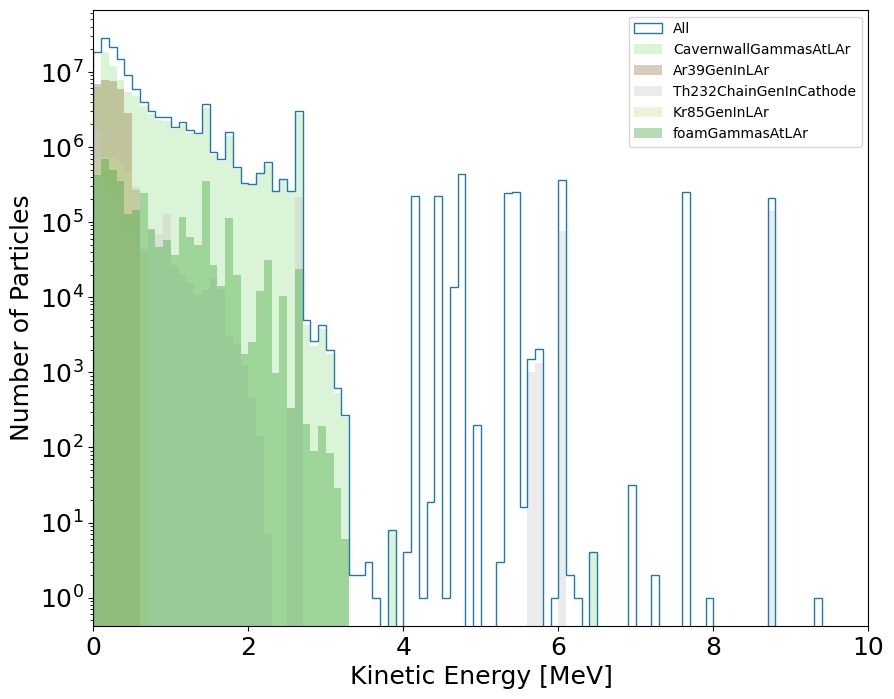

In [19]:
fig, ax = plt.subplots(figsize = (10, 8))

fontS = 18

ax.hist(df.Ekin*1000, bins = Ebins, histtype = 'step', label = 'All')
for radMap in top5_with_names.itertuples(index = False):
    ax.hist(df.loc[df['labelcode'].eq(radMap.labelCode), 'Ekin']*1000, bins = Ebins, histtype = 'stepfilled', alpha = 0.35, 
            label = radMap.label, color = radMap.color)

ax.set_xlabel('Kinetic Energy [MeV]', fontsize = fontS)
ax.set_ylabel('Number of Particles', fontsize = fontS)
ax.tick_params(axis = "both", labelsize = fontS)
ax.set_xlim([0, 10])
ax.set_yscale('log')
ax.legend()

In [14]:
df[df.labelcode == 2531678975].Ekin.max()

0.00057687637782588

In [15]:
df.Ekin.max(), df.Etot.max()

(0.009300796198411879, 3.7362019999999996)

In [16]:
EkinMin3MeV_mask = df.Ekin > 0.003

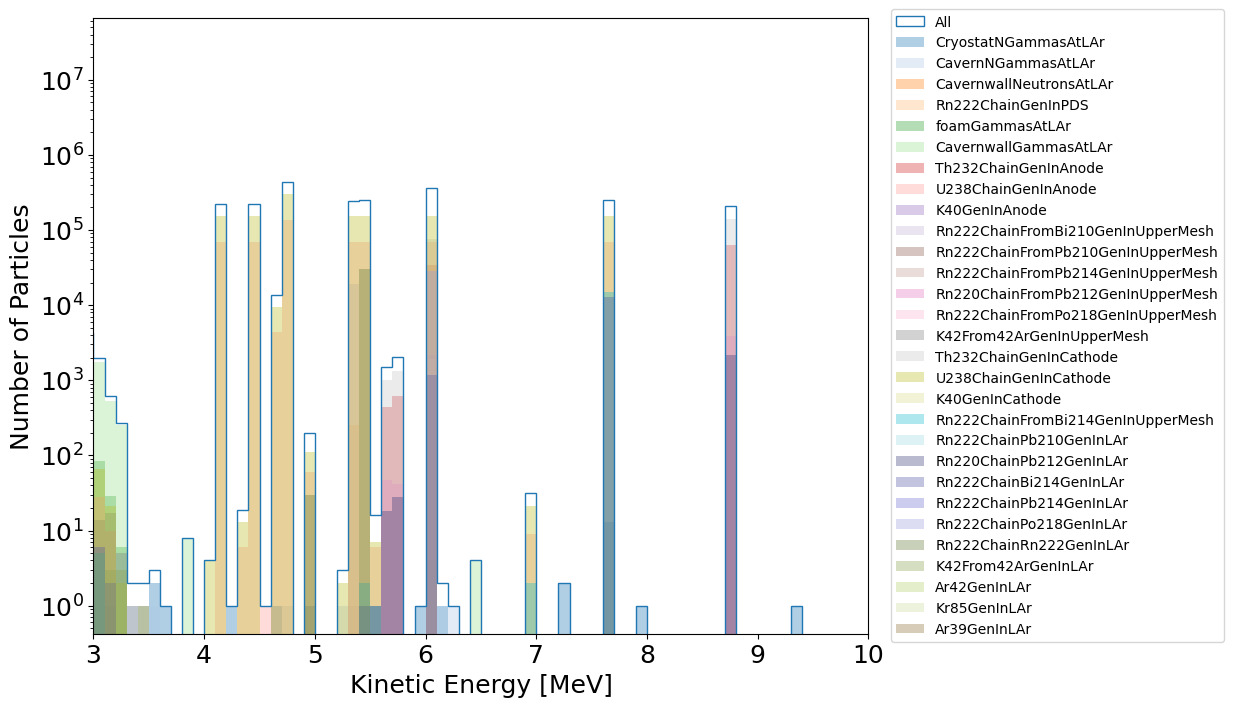

In [20]:
fig, ax = plt.subplots(figsize = (10, 8))

fontS = 18

ax.hist(df.Ekin*1000, bins = Ebins, histtype = 'step', label = 'All')
for radMap in labelDF.itertuples(index = False):
    ax.hist(df.loc[df['labelcode'].eq(radMap.labelCode) & EkinMin3MeV_mask, 'Ekin']*1000, bins = Ebins, histtype = 'stepfilled', alpha = 0.35,
            label = radMap.label, color = radMap.color)

ax.set_xlabel('Kinetic Energy [MeV]', fontsize = fontS)
ax.set_ylabel('Number of Particles', fontsize = fontS)
ax.tick_params(axis = "both", labelsize = fontS)
ax.set_xlim([3, 10])
ax.set_yscale('log')
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5))

In [22]:
top5Egt3 = ( df[EkinMin3MeV_mask]["labelcode"].value_counts().head(5).rename_axis('labelCode').reset_index(name = 'count') )
# top5_codes = top5_codes.rename(columns = {"index": "labelCode"})
top5Egt3

top5Egt3_with_names = top5Egt3.merge(labelDF[["labelCode", "label", "color"]], on = "labelCode", how = "left")
top5Egt3_with_names

,labelCode,count,label,color
0,1043031774,1227920,U238ChainGenInCathode,"[0.7372549019607844, 0.7411764705882353, 0.133..."
1,597414879,554327,U238ChainGenInAnode,"[1.0, 0.596078431372549, 0.5882352941176471]"
2,3444384594,217435,Th232ChainGenInCathode,"[0.7803921568627451, 0.7803921568627451, 0.780..."
3,871716743,97831,Th232ChainGenInAnode,"[0.8392156862745098, 0.15294117647058825, 0.15..."
4,2533298584,30469,Rn222ChainRn222GenInLAr,"[0.38823529411764707, 0.4745098039215686, 0.22..."


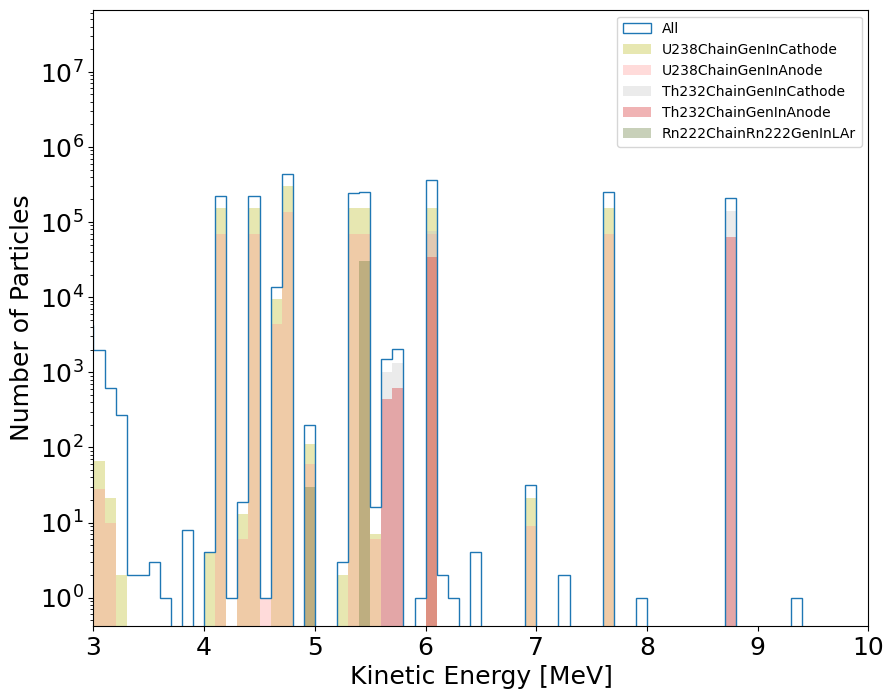

In [24]:
fig, ax = plt.subplots(figsize = (10, 8))

ax.hist(df.Ekin*1000, bins = Ebins, histtype = 'step', label = 'All')
for radMap in top5Egt3_with_names.itertuples(index = False):
    ax.hist(df.loc[df['labelcode'].eq(radMap.labelCode) & EkinMin3MeV_mask, 'Ekin']*1000, bins = Ebins, histtype = 'stepfilled', 
            color = radMap.color, alpha = 0.35, label = radMap.label)

ax.set_xlabel('Kinetic Energy [MeV]', fontsize = 18)
ax.set_ylabel('Number of Particles', fontsize = 18)
ax.tick_params(axis = "both", labelsize = 18)
ax.set_xlim([3, 10])
ax.set_yscale('log')
ax.legend()

In [25]:
df['pdg_code'].unique()

array([        11,         22, 1000020040,        -11,       2112],
      dtype=int32)

In [28]:
pdgcodes = df['pdg_code'].unique()

# build mapping using labelDF order
pdg_to_color = dict(zip(pdgcodes, palette))
pdg_to_name = { 11: 'electron', 22: 'gamma', 1000020040: 'alpha', -11: 'positron', 2112: 'neutron' }

pdgDF = pandas.DataFrame({
    "pdg_code": pdgcodes,
    "color": [pdg_to_color[p] for p in pdgcodes],
    "particle": [pdg_to_name[p] for p in pdgcodes],
})
pdgDF

,pdg_code,color,particle
0,11,"[0.12156862745098039, 0.4666666666666667, 0.70...",electron
1,22,"[0.6823529411764706, 0.7803921568627451, 0.909...",gamma
2,1000020040,"[1.0, 0.4980392156862745, 0.054901960784313725]",alpha
3,-11,"[1.0, 0.7333333333333333, 0.47058823529411764]",positron
4,2112,"[0.17254901960784313, 0.6274509803921569, 0.17...",neutron


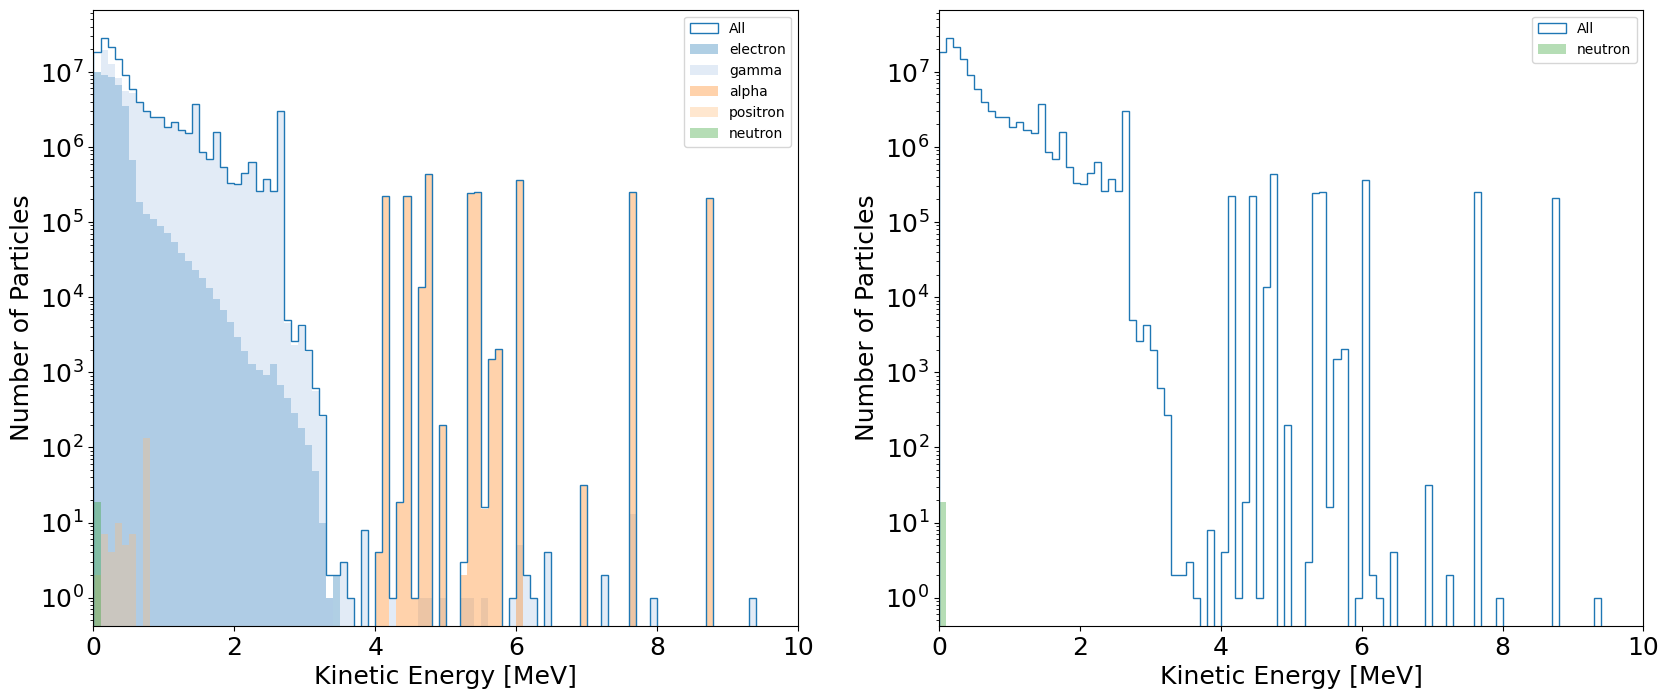

In [29]:
fig, ax = plt.subplots(1, 2, figsize = (20, 8))

fontS = 18

ax[0].hist(df.Ekin*1000, bins = Ebins, histtype = 'step', label = 'All')
for radMap in pdgDF.itertuples(index = False):
    ax[0].hist(df.loc[df['pdg_code'].eq(radMap.pdg_code), 'Ekin']*1000, bins = Ebins, histtype = 'stepfilled', 
               alpha = 0.35, color = radMap.color, label = radMap.particle)

pdg_code = 2112
ax[1].hist(df.Ekin*1000, bins = Ebins, histtype = 'step', label = 'All')
ax[1].hist(df.loc[df['pdg_code'].eq(pdg_code), 'Ekin']*1000, bins = Ebins, histtype = 'stepfilled', color = pdgDF[pdgDF.pdg_code == pdg_code].color,
           alpha = 0.35,
           label = pdgDF[pdgDF.pdg_code == pdg_code].particle)

for i in range(2):
    ax[i].set_xlabel('Kinetic Energy [MeV]', fontsize = fontS)
    ax[i].set_ylabel('Number of Particles', fontsize = fontS)
    ax[i].tick_params(axis = "both", labelsize = fontS)
    ax[i].set_xlim([0, 10])
    ax[i].set_yscale('log')
    ax[i].legend()

In [30]:
activeVol_mask = (df.x >= -325) & (df.x <= 325)

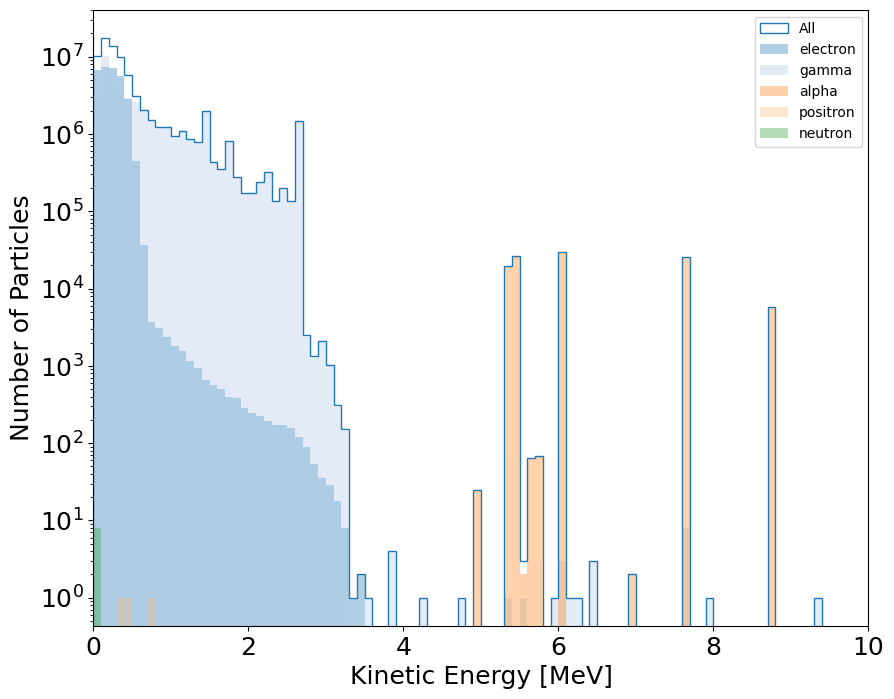

In [32]:
fig, ax = plt.subplots(figsize = (10, 8))

fontS = 18

ax.hist(df[activeVol_mask].Ekin*1000, bins = Ebins, histtype = 'step', label = 'All')
for radMap in pdgDF.itertuples(index = False):
    ax.hist(df.loc[df['pdg_code'].eq(radMap.pdg_code) & activeVol_mask, 'Ekin']*1000, bins = Ebins, histtype = 'stepfilled', 
            color = radMap.color, alpha = 0.35, label = radMap.particle)

ax.set_xlabel('Kinetic Energy [MeV]', fontsize = fontS)
ax.set_ylabel('Number of Particles', fontsize = fontS)
ax.tick_params(axis = "both", labelsize = fontS)
ax.set_xlim([0, 10])
ax.set_yscale('log')
ax.legend()

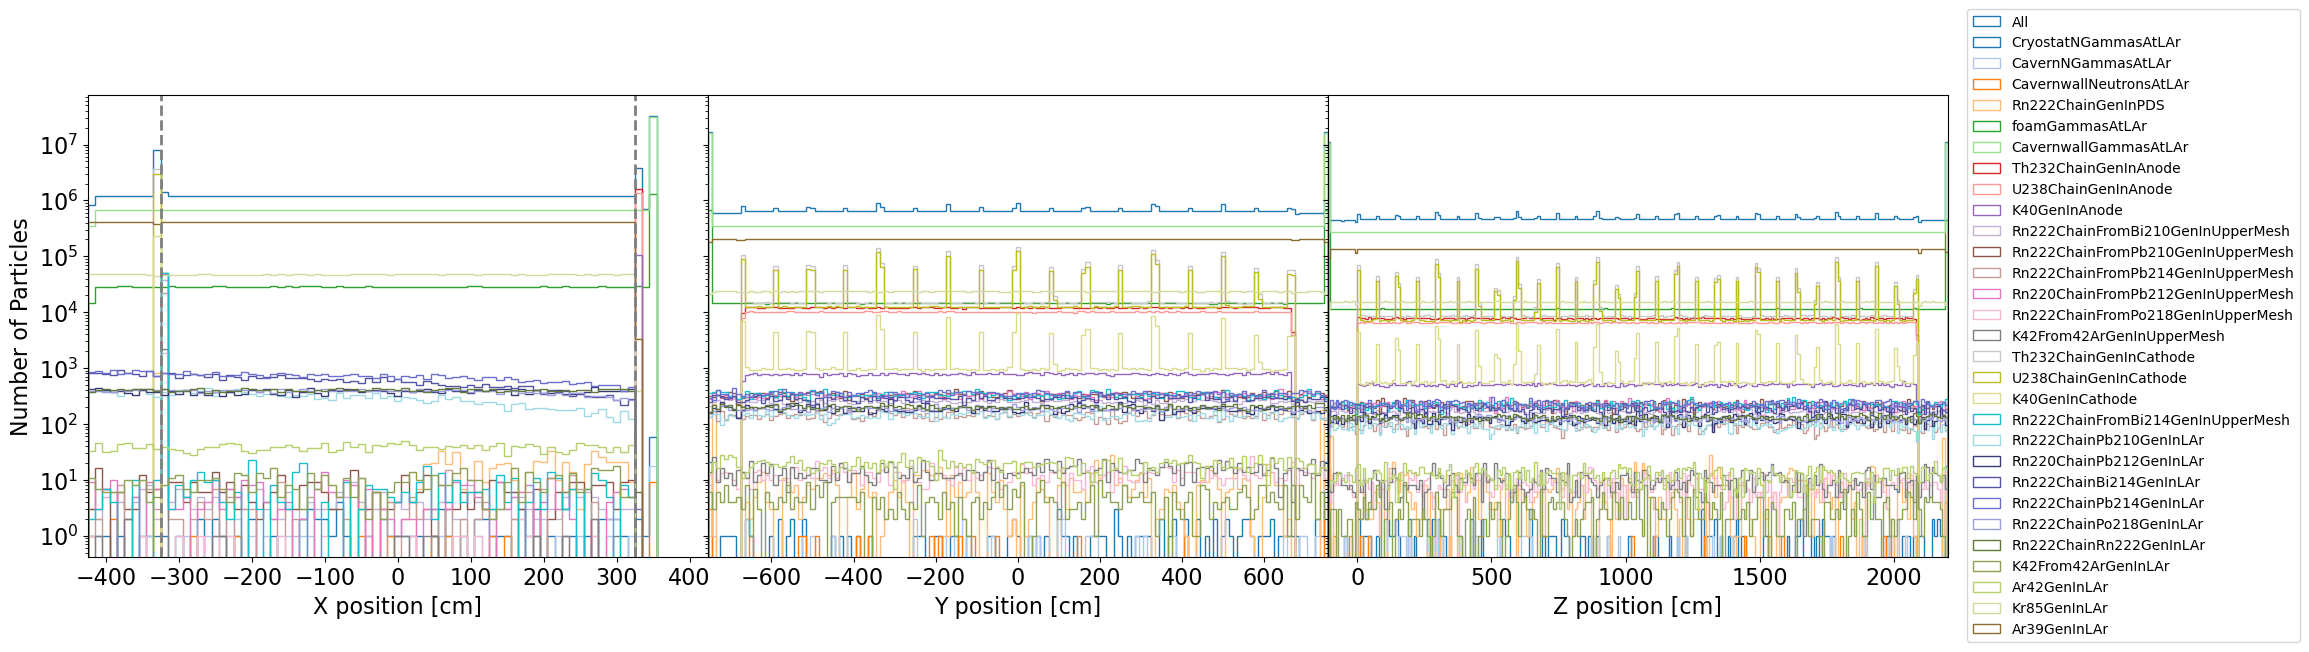

In [34]:
fig, ax = plt.subplots(1, 3, figsize = (24, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

xbins = np.linspace(-425, 425, 86)
ybins = np.linspace(-755, 755, 152)
zbins = np.linspace(-110, 2200, 232)

fontS = 16

## X
ax[0].hist(df.x, bins = xbins, histtype = 'step', label = 'All')
for radMap in labelDF.itertuples(index = False):
    ax[0].hist(df.loc[df['labelcode'].eq(radMap.labelCode), 'x'], bins = xbins, histtype = 'step', 
               color = radMap.color, label = radMap.label)

ax[0].axvline(x = -325, color = "tab:grey", linestyle = "--", linewidth = 2) 
ax[0].axvline(x = 325, color = "tab:grey", linestyle = "--", linewidth = 2) 

ax[0].set_xlabel('X position [cm]', fontsize = fontS)
ax[0].set_ylabel('Number of Particles', fontsize = fontS)
ax[0].set_xlim([-425, 425])

## Y
ax[1].hist(df.y, bins = ybins, histtype = 'step', label = 'All')
for radMap in labelDF.itertuples(index = False):
    ax[1].hist(df.loc[df['labelcode'].eq(radMap.labelCode), 'y'], bins = ybins, histtype = 'step',
               color = radMap.color, label = radMap.label)

ax[1].set_xlabel('Y position [cm]', fontsize = fontS)
ax[1].set_xlim([-755, 755])

## Z
ax[2].hist(df.z, bins = zbins, histtype = 'step', label = 'All')
for radMap in labelDF.itertuples(index = False):
    ax[2].hist(df.loc[df['labelcode'].eq(radMap.labelCode), 'z'], bins = zbins, histtype = 'step',
               color = radMap.color, label = radMap.label)

ax[2].set_xlabel('Z position [cm]', fontsize = fontS)
ax[2].set_xlim([-110, 2200])

## Common
for i in range(3):
    ax[i].tick_params(axis = "both", labelsize = fontS)
    ax[i].set_yscale('log')

ax[2].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5))

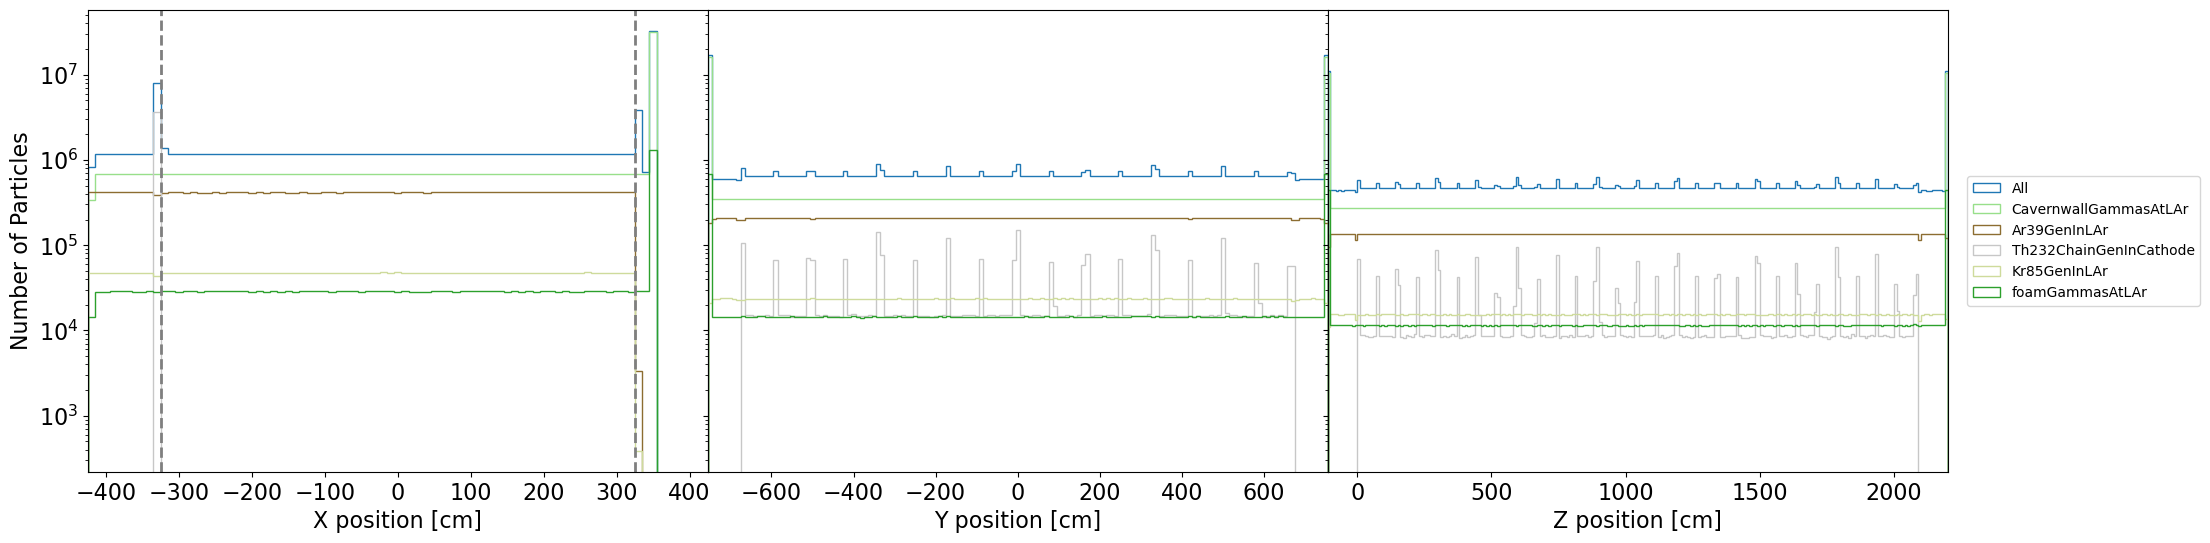

In [35]:
fig, ax = plt.subplots(1, 3, figsize = (24, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

xbins = np.linspace(-425, 425, 86)
ybins = np.linspace(-755, 755, 152)
zbins = np.linspace(-110, 2200, 232)

fontS = 16

## X
ax[0].hist(df.x, bins = xbins, histtype = 'step', label = 'All')
for radMap in top5_with_names.itertuples(index = False):
    ax[0].hist(df.loc[df['labelcode'].eq(radMap.labelCode), 'x'], bins = xbins, histtype = 'step', color = radMap.color, label = radMap.label)

ax[0].axvline(x = -325, color = "tab:grey", linestyle = "--", linewidth = 2) 
ax[0].axvline(x = 325, color = "tab:grey", linestyle = "--", linewidth = 2) 

ax[0].set_xlabel('X position [cm]', fontsize = fontS)
ax[0].set_ylabel('Number of Particles', fontsize = fontS)
ax[0].set_xlim([-425, 425])

## Y
ax[1].hist(df.y, bins = ybins, histtype = 'step', label = 'All')
for radMap in top5_with_names.itertuples(index = False):
    ax[1].hist(df.loc[df['labelcode'].eq(radMap.labelCode), 'y'], bins = ybins, histtype = 'step', color = radMap.color, label = radMap.label)

ax[1].set_xlabel('Y position [cm]', fontsize = fontS)
ax[1].set_xlim([-755, 755])

## Z
ax[2].hist(df.z, bins = zbins, histtype = 'step', label = 'All')
for radMap in top5_with_names.itertuples(index = False):
    ax[2].hist(df.loc[df['labelcode'].eq(radMap.labelCode), 'z'], bins = zbins, histtype = 'step', color = radMap.color, label = radMap.label)

ax[2].set_xlabel('Z position [cm]', fontsize = fontS)
ax[2].set_xlim([-110, 2200])

## Common
for i in range(3):
    ax[i].tick_params(axis = "both", labelsize = fontS)
    ax[i].set_yscale('log')

ax[2].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5))

Cavern wall gamma: where are they flat?  is  this trunk close to the edge?  make further plots 

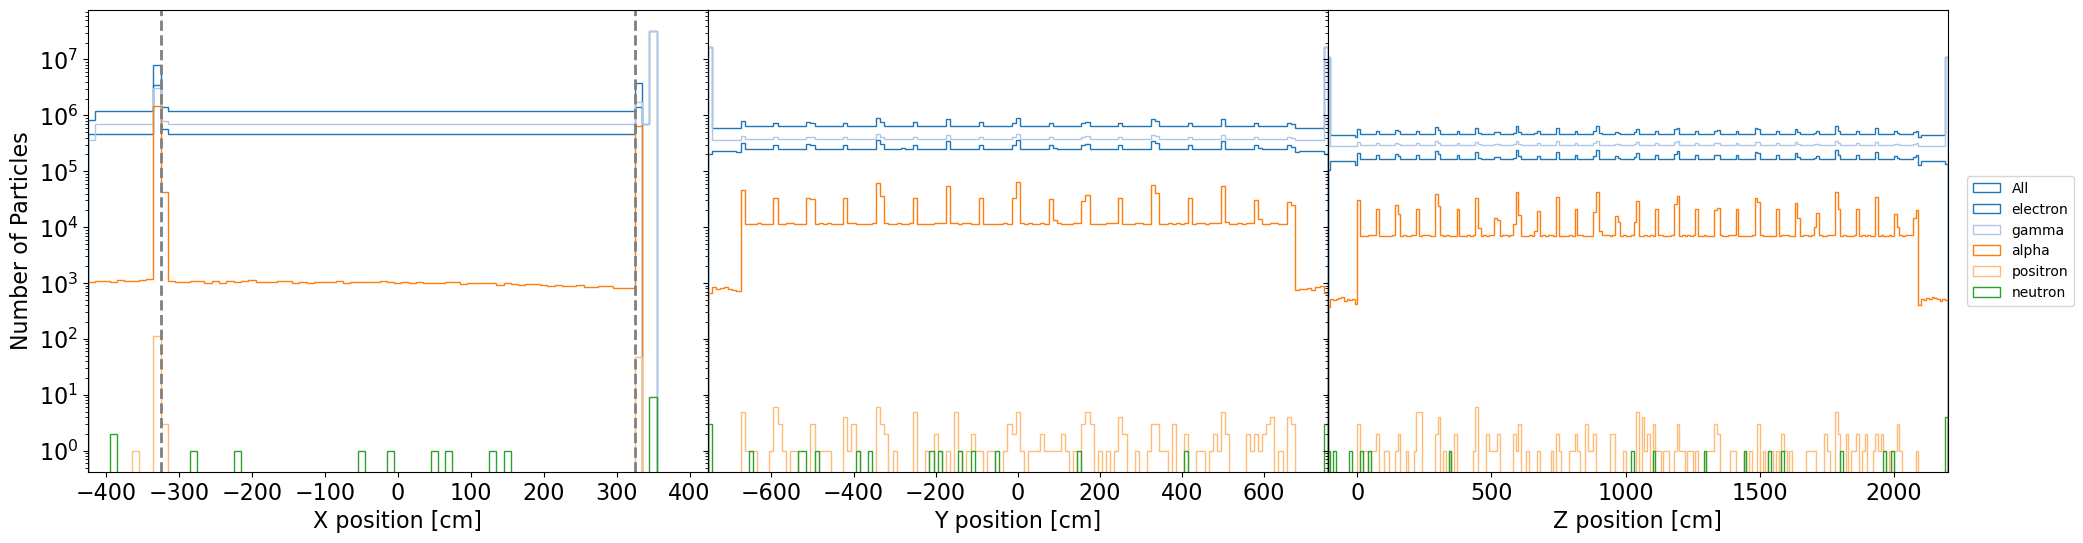

In [36]:
fig, ax = plt.subplots(1, 3, figsize = (24, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

xbins = np.linspace(-425, 425, 86)
ybins = np.linspace(-755, 755, 152)
zbins = np.linspace(-110, 2200, 232)

fontS = 16

## X
ax[0].hist(df.x, bins = xbins, histtype = 'step', label = 'All')
for radMap in pdgDF.itertuples( index = False ):
    ax[0].hist(df.loc[df['pdg_code'].eq(radMap.pdg_code), 'x'], bins = xbins, histtype = 'step', color = radMap.color, 
               label = radMap.particle)

ax[0].axvline(x = -325, color = "tab:grey", linestyle = "--", linewidth = 2) 
ax[0].axvline(x = 325, color = "tab:grey", linestyle = "--", linewidth = 2) 

ax[0].set_xlabel('X position [cm]', fontsize = fontS)
ax[0].set_ylabel('Number of Particles', fontsize = fontS)
ax[0].set_xlim([-425, 425])

## Y
ax[1].hist(df.y, bins = ybins, histtype = 'step', label = 'All')
for radMap in pdgDF.itertuples(index = False):
    ax[1].hist(df.loc[df['pdg_code'].eq(radMap.pdg_code), 'y'], bins = ybins, histtype = 'step', color = radMap.color,
               label = radMap.particle)

ax[1].set_xlabel('Y position [cm]', fontsize = fontS)
ax[1].set_xlim([-755, 755])

## Z
ax[2].hist(df.z, bins = zbins, histtype = 'step', label = 'All')
for radMap in pdgDF.itertuples(index = False):
    ax[2].hist(df.loc[df['pdg_code'].eq(radMap.pdg_code), 'z'], bins = zbins, histtype = 'step', color = radMap.color,
               label = radMap.particle)

ax[2].set_xlabel('Z position [cm]', fontsize = fontS)
ax[2].set_xlim([-110, 2200])

## Common
for i in range(3):
    ax[i].tick_params(axis = "both", labelsize = fontS)
    ax[i].set_yscale('log')

ax[2].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5))

In [37]:
df.t.min(), df.t.max()

(-4284999.489188194, 6472926.765967784)

In [38]:
df.x.min(), df.x.max(), df.y.min(), df.y.max(), df.z.min(), df.z.max()

(-424.9999826049806,
 350.49999994039536,
 -753.8023275962831,
 753.8023275962828,
 -106.99986392498005,
 2198.8798639249803)

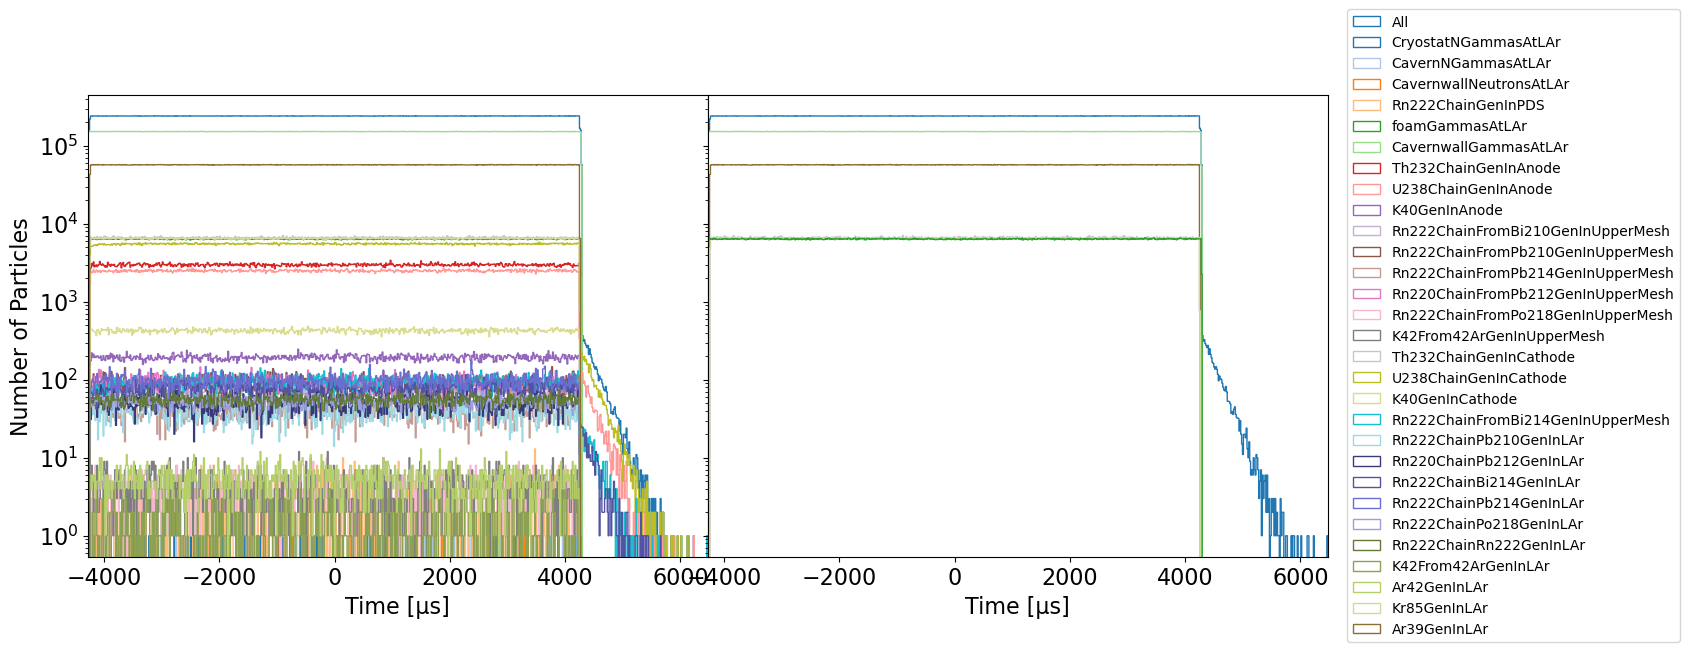

In [41]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

tbins = np.linspace(-4285, 6475, 692)
fontS = 16

## All sources
ax[0].hist(df.t/1000, bins = tbins, histtype = 'step', label = 'All')
for radMap in labelDF.itertuples(index = False):
    ax[0].hist(df.loc[df['labelcode'].eq(radMap.labelCode), 't']/1000, bins = tbins, histtype = 'step', color = radMap.color,
    label = radMap.label)

ax[0].set_ylabel('Number of Particles', fontsize = fontS)

## Top 5 sources
ax[1].hist(df.t/1000, bins = tbins, histtype = 'step', label = 'All')
for radMap in top5_with_names.itertuples(index = False):
    ax[1].hist(df.loc[df['labelcode'].eq(radMap.labelCode), 't']/1000, bins = tbins, histtype = 'step', color = radMap.color,
               label = radMap.label)

ax[0].legend(loc = "center left", bbox_to_anchor = (2.02, 0.5))

## Common
for i in range(2):
    ax[i].set_xlabel('Time [µs]', fontsize = fontS)
    ax[i].set_xlim([-4285, 6475])
    ax[i].tick_params(axis = "both", labelsize = fontS)
    ax[i].set_yscale('log')

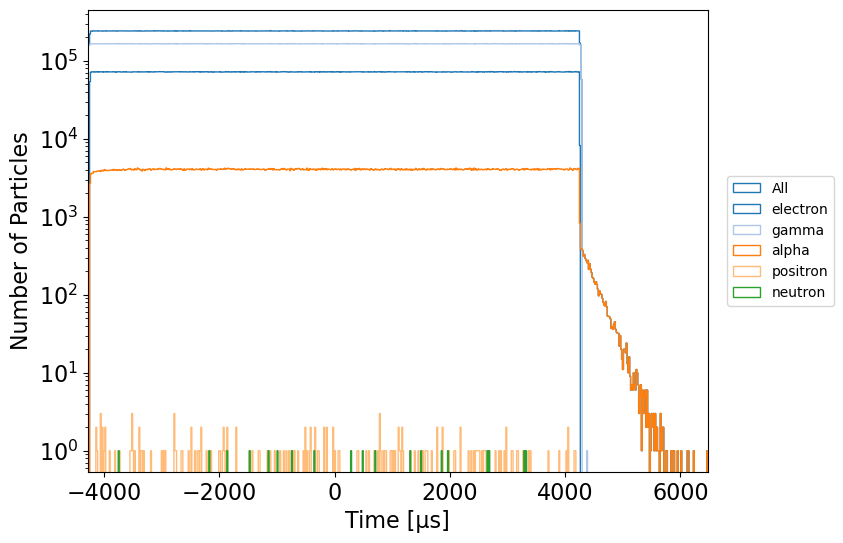

In [42]:
fig, ax = plt.subplots(figsize = (8, 6))

tbins = np.linspace(-4285, 6475, 692)
fontS = 16

ax.hist(df.t/1000, bins = tbins, histtype = 'step', label = 'All')
for radMap in pdgDF.itertuples(index = False):
    ax.hist(df.loc[df['pdg_code'].eq(radMap.pdg_code), 't']/1000, bins = tbins, histtype = 'step', color = radMap.color,
            label = radMap.particle)

ax.set_xlabel('Time [µs]', fontsize = fontS)
ax.set_xlim([-4285, 6475])
ax.tick_params(axis = "both", labelsize = fontS)
ax.set_yscale('log')
ax.set_ylabel('Number of Particles', fontsize = fontS)
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5))

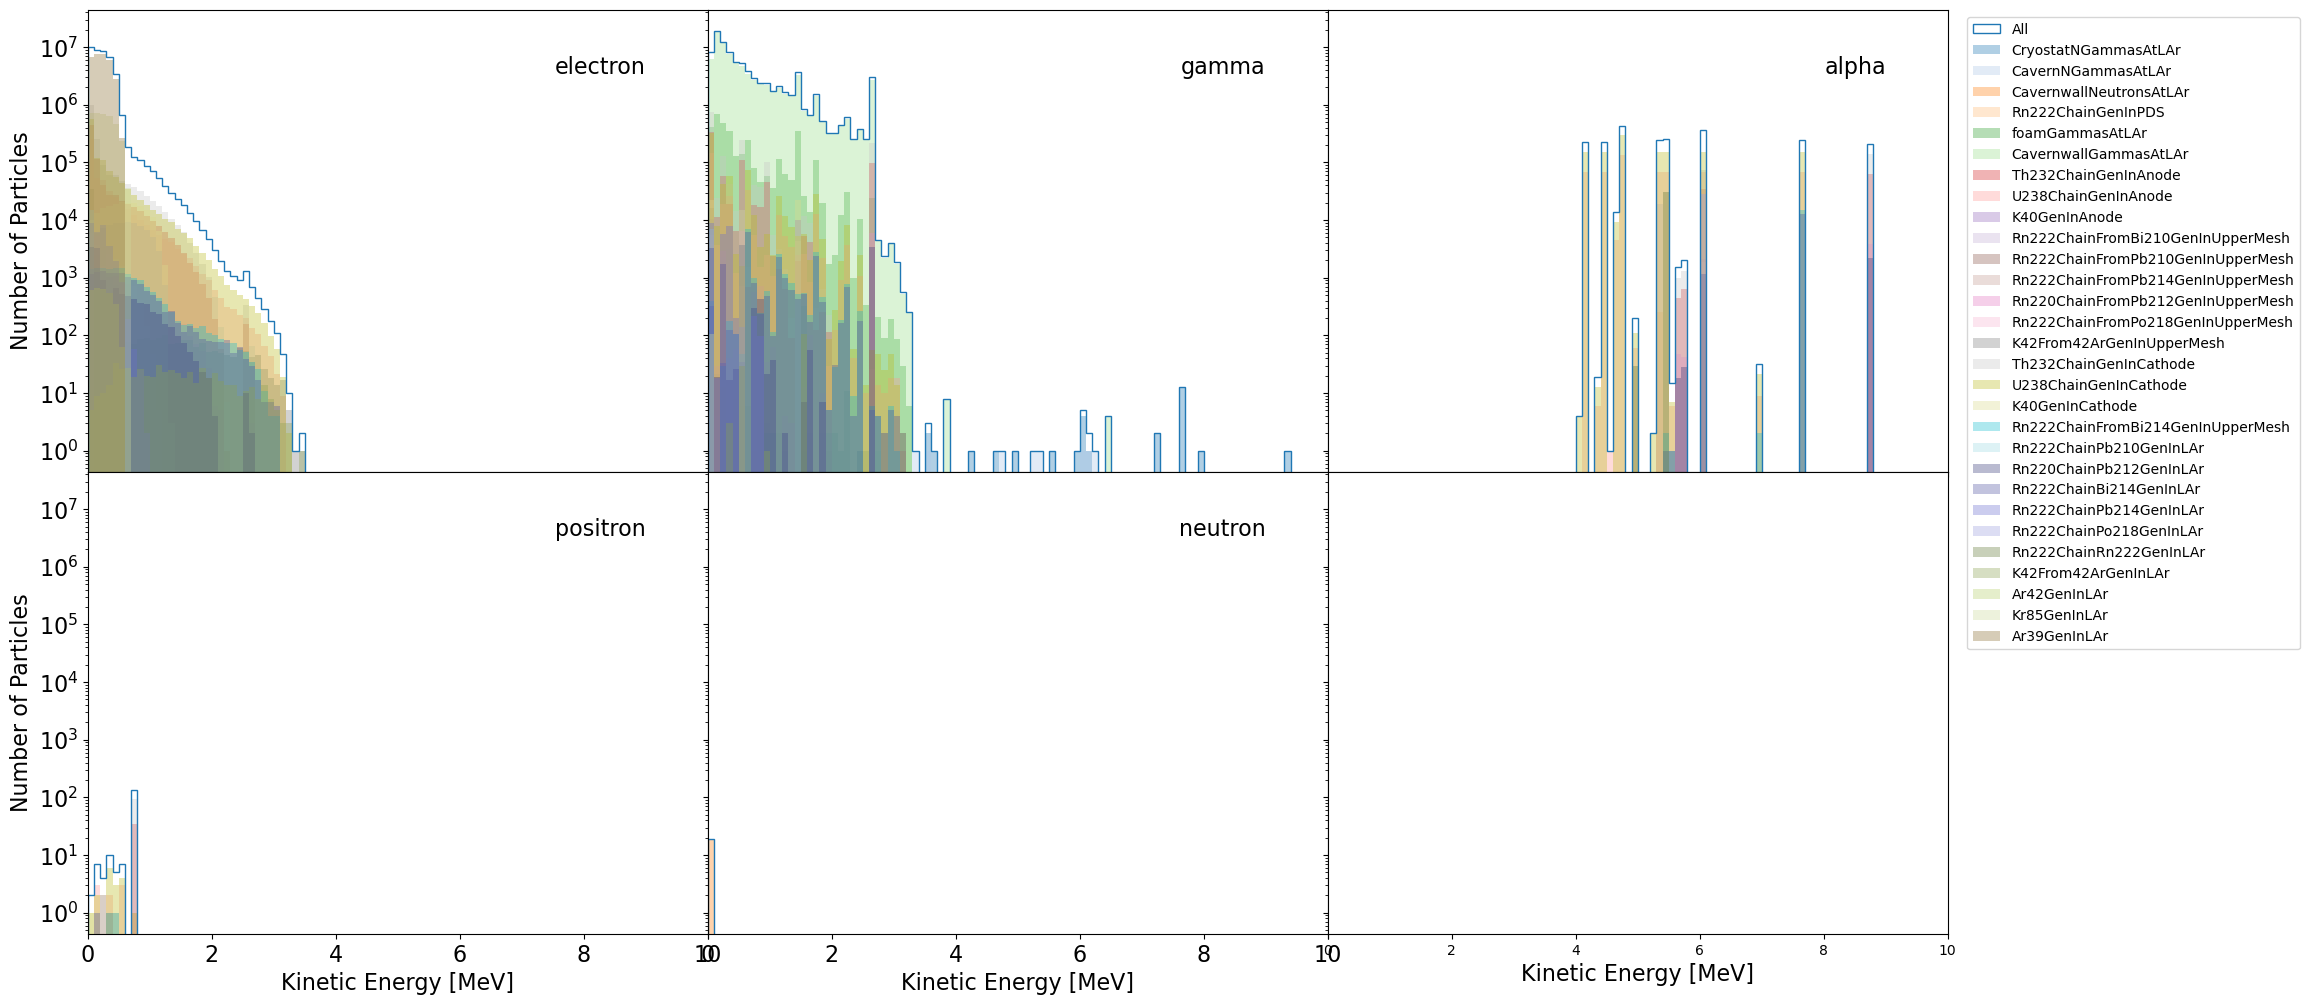

In [48]:
fig, ax = plt.subplots(2, 3, figsize = (24, 12), sharey = True, sharex = True)
fig.subplots_adjust(wspace = 0, hspace = 0)  # remove gaps between panels

fontS = 16

for i in range(2):
    for j in range(3):
        if i == 1 and j == 2:
            break
        k = i*3+j
        ax[i][j].hist(df.loc[df['pdg_code'].eq(pdgDF.loc[k]['pdg_code']), 'Ekin']*1000, bins = Ebins, histtype = 'step', label = 'All')
        for radMap in labelDF.itertuples(index = False):
            ax[i][j].hist(df.loc[df['pdg_code'].eq(pdgDF.loc[k]['pdg_code']) & df['labelcode'].eq(radMap.labelCode), 'Ekin']*1000, bins = Ebins, 
                       histtype = 'stepfilled', color = radMap.color, alpha = 0.35, label = radMap.label)

        ax[1][j].set_xlabel('Kinetic Energy [MeV]', fontsize = fontS)
        ax[i][j].tick_params(axis = "both", labelsize = fontS)
        ax[i][j].set_xlim([0, 10])
        ax[i][j].set_yscale('log')
        # ax[i][j].set_title( pdgDF.loc[k]['particle'], fontsize = fontS)
        ax[i][j].text(
            0.9, 0.9, pdgDF.loc[k]['particle'],
            transform = ax[i][j].transAxes,
            ha = "right", va = "top",
            fontsize = fontS,
            bbox = dict(boxstyle = "round,pad = 0.3", fc = "white", alpha = 0.7, ec = "none"),
        )

    ax[i][0].set_ylabel('Number of Particles', fontsize = fontS)

ax[0][2].legend(loc = "center left", bbox_to_anchor = (1.02, 0.3))

In [94]:
pdgcodes[0]

np.int32(11)

In [43]:
pdgDF.loc[0]

pdg_code                                                   11
color       [0.12156862745098039, 0.4666666666666667, 0.70...
particle                                             electron
Name: 0, dtype: object

In [44]:
pdgDF.loc[0]['pdg_code']

np.int32(11)